In [26]:
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import heapq
import signal

In [2]:
class TreeNode:
    def __init__(self, level, V, W, taken, upper_bound=None):
        self.level = level  # niveau dans l’arbre de recherche >=0
        self.V = V  # valeur de la solution courante
        self.W = W  # poids de la solution courante
        self.taken = taken  # liste des index d’objets de la solution courante
        self.upper_bound = upper_bound  # Upper Bound of the solution (for Best First method)

    def __lt__(self, other):
        return (self.upper_bound or 0) > (other.upper_bound or 0)  # Highest bound has priority
    

class KPBB_BestFirst:
    def __init__(self, values, weights, cap): 
        self.capacity = cap
        self.values = values
        self.weights = weights
        self.unordered = [((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))]
        self.ordered = sorted([((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))], key=lambda tup: float(tup[0][0])/tup[0][1], reverse=True)
    
    def UpperBound(self, node): # calcul UpperBound
        W = self.capacity - node.W # remaining capacity
        result = node.V
        i = node.level + 1 # next level
        
        while i < len(self.ordered) and self.ordered[i][0][1] <= W: # while there are itens left and it fits
            W -= self.ordered[i][0][1] # reduces capacity
            result += self.ordered[i][0][0] # ads it to the sac a dos
            i += 1 # goes to next item
        
        if i < len(self.ordered): # when no more itens fits, ads a fraction of the following item
            result += self.ordered[i][0][0] * (W / self.ordered[i][0][1]) 
        return result

    def solve(self):
        root = TreeNode(-1, 0, 0, [], self.UpperBound(TreeNode(-1, 0, 0, [], 0)))  # root node
        queue = []
        heapq.heappush(queue, root)

        self.bestValue = 0
        self.bestTaken = []

        self.n_it = 0

        while queue:
            node = heapq.heappop(queue)
            self.n_it = self.n_it + 1

            if node.upper_bound <= self.bestValue:
                continue  # Cuts the node

            if node.level < len(self.ordered) - 1:
                # Caso 1: Incluir o item
                item = self.ordered[node.level + 1]
                nodeRight = TreeNode(node.level + 1, node.V + item[0][0], node.W + item[0][1], node.taken + [item[1]], self.UpperBound(node))
                
                if nodeRight.W <= self.capacity and nodeRight.V > self.bestValue:
                    self.bestValue = nodeRight.V
                    self.bestTaken = nodeRight.taken

                if nodeRight.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeRight)

                # Caso 2: Não incluir o item
                nodeLeft = TreeNode(node.level + 1, node.V, node.W, node.taken, self.UpperBound(node))
                
                if nodeLeft.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeLeft)

        return self.bestValue, self.bestTaken, self.n_it    
    
    
def knapsack_BU(values, weights, W):
    W = int(W) 
    n = len(values) 

    dp = [[0] * (W + 1) for _ in range(n + 1)] # Zero Matrix with (n+1) rows and (W+1) columns 
    n_it = 0

    for i in range(n): # for each item 
        n_it = n_it + 1
        wi = int(weights[i]) 

        for x in range(W + 1):  # Cycle through all possible backpack capacities
            # If you don't get the current item
            dp[i + 1][x] = dp[i][x]

            #  Possibility 2: take the item 
            if wi <= x: # checks if it fits in the backpack
                dp[i + 1][x] = max(dp[i + 1][x], values[i] + dp[i][x - wi])

    # The maximum possible value is in the last cell of the matrix
    return dp[n][W], n_it 

## Exercice 1 – Recuit simulé pour le problème du sac à dos 0/1

On vous demande dans cet exercice de programmer un algorithme de recuit simulé pour résoudre le problème
du sac à dos 0/1. Vous testerez votre algorithme sur les données fournies lors des séances précédentes. Vous
comparerez statistiquement (donc en faisant de multiples run de votre algorithme, ce qui est indispensable
quand l’aléatoire intervient) les résultats de votre algorithme avec ceux obtenus par une stratégie déterministe,
consistant à accepter uniquement les solutions améliorantes. Vous pourrez également :

- comparer les solutions obtenues avec les solutions optimales.
- analyser l’impact des différents paramètres de l’algorithme.

Pour générer un voisin à partir d’une solution initiale, plusieurs options pourront être imaginées. Une pos-
sibilité consiste à :

1. Tirer aléatoirement un objet non présent dans le sac
2. Ajouter cet objet
3. Tant que le poids du sac dépasse la capacité maximale :

(a) Tirer aléatoirement un objet présent dans le sac

(b) Supprimer cet objet

In [3]:

def initial_solution(weights, values, wmax):
    W = int(wmax) 
    n = len(weights) 
    selected = np.zeros(n, dtype=int)
    result = 0

    while W >= 0 and np.any(selected == 0):  # Garante que há itens para adicionar
        i = np.random.randint(n)
        if selected[i] == 0 and W >= weights[i]:  # Apenas adiciona se houver espaço
            selected[i] = 1
            W -= weights[i]
            result += values[i]

    return result, W, selected

In [4]:
def Knapsack_DA(weights, values, wmax):
    result, W, selected = initial_solution(weights, values, wmax)
    n = len(weights)

    Best_list = selected.copy()
    Best_result = result
    Best_W = W

    print(f"{Best_list}, {Best_W}, {Best_result} (Initial)\n")

    for iteration in range(1000): 
        voisin_list = Best_list.copy()
        voisin_result = Best_result
        voisin_W = Best_W
        
        i = np.random.randint(n)
        if voisin_list[i] == 0 and voisin_W >= weights[i]:  # Apenas adiciona se houver espaço
            voisin_list[i] = 1
            voisin_W -= weights[i]
            voisin_result += values[i]

            print(f"{voisin_list}, {voisin_W}, {voisin_result} (add{i}, {weights[i]}, {values[i]})")

            while voisin_W < 0:
                j = np.random.randint(n)
                if voisin_list[j] == 1:
                    voisin_list[j] = 0
                    voisin_W += weights[j]
                    voisin_result -= values[j]
                    print(f"{voisin_list}, {voisin_W}, {voisin_result} (remove{j}, {weights[j]}, {values[j]})")

            if voisin_result >= Best_result:
                Best_list = voisin_list.copy()
                Best_W = voisin_W 
                Best_result = voisin_result

                print(f"{Best_list}, {Best_W}, {Best_result} (New Best)\n")

    return Best_result, Best_list
    

In [7]:
def initial_solution(weights, values, wmax):
    """Gera uma solução inicial viável para o problema da mochila."""
    n = len(weights)
    selected = np.zeros(n, dtype=int)
    W = wmax
    result = 0

    indices = np.random.permutation(n)  # Embaralha os índices para melhor aleatoriedade

    for i in indices:
        if W >= weights[i]:
            selected[i] = 1
            W -= weights[i]
            result += values[i]

    return selected, result, W

def knapsack_value(selected, weights, values):
    """Calcula o valor total e o peso de uma configuração."""
    value = np.dot(selected, values)
    weight = np.dot(selected, weights)
    return value, weight

def get_neighbor(selected, weights, values, wmax):
    """Gera uma solução vizinha ao modificar um item da configuração atual."""
    neighbor = selected.copy()
    n = len(weights)

    i = np.random.randint(n)
    neighbor[i] = 1 - neighbor[i]  # Alterna entre 0 e 1 (adiciona ou remove item)

    new_value, new_weight = knapsack_value(neighbor, weights, values)

    # Se ultrapassar o peso máximo, reverte a mudança
    if new_weight > wmax:
        neighbor[i] = selected[i]  # Desfaz a mudança
        new_value, new_weight = knapsack_value(neighbor, weights, values)

    return neighbor, new_value, new_weight

def simulated_annealing_knapsack(values, weights, wmax, T0=100, coeff=0.99, iter_step=100, stop_threshold=0.001):
    """Resolve o problema da mochila 0/1 usando Simulated Annealing."""
    
    # Inicialização
    current_solution, current_value, current_weight = initial_solution(weights, values, wmax)
    best_solution = current_solution.copy()
    best_value = current_value
    T = T0
    n_it = 0

    # Loop principal
    while T > stop_threshold:
        n_it = n_it +1
        nb_moves = 0
        for i in range(iter_step):
            # Gera vizinho
            new_solution, new_value, new_weight = get_neighbor(current_solution, weights, values, wmax)
            
            # Calcula delta em relação à solução ATUAL
            delta = new_value - current_value

            # Critério de Metropolis
            if delta > 0 or np.random.rand() < np.exp(delta / T):
                current_solution = new_solution.copy()
                current_value = new_value
                current_weight = new_weight
                nb_moves += 1

                # Atualiza melhor solução encontrada
                if current_value > best_value:
                    best_solution = current_solution.copy()
                    best_value = current_value

        # Atualiza a temperatura
        acceptance_rate = nb_moves / iter_step if iter_step > 0 else 0
        if acceptance_rate < stop_threshold:
            break  # Critério de parada se a aceitação for muito baixa
        T *= coeff

    return best_solution, best_value, n_it


### Single Test

In [8]:
path = "./instances_01_KP/low-dimensional/f10_l-d_kp_20_879" 
dataset = np.loadtxt(path)

n = int(dataset[0][0])
wmax = dataset[0][1]
itens = dataset[1:]

weights = dataset[1:,1]
values = dataset[1:,0]

print(weights)
print(values)

[84. 83. 43.  4. 44.  6. 82. 92. 25. 83. 56. 18. 58. 14. 48. 70. 96. 32.
 68. 92.]
[91. 72. 90. 46. 55.  8. 35. 75. 61. 15. 77. 40. 63. 75. 29. 75. 17. 78.
 40. 44.]


In [10]:
methods = {
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

times = {method: [] for method in methods}
n_values = []

for method_name, method in methods.items():
    tic = time.perf_counter()

    if method_name == "Simulated Annealing":
        bestTaken, best_value, n_it = method(values, weights, wmax)  
        print("Estimated Best value:", bestValue)
    elif method_name == "Bottom-Up":
        bestValue, n_it = method(values, weights, wmax)  
        print("Optimal value:", bestValue)
        bestTaken = None
    else:
        knapsack_solver = method(values, weights, wmax)
        print("Chosen itens:", bestTaken)
        bestValue, bestTaken, n_it = knapsack_solver.solve()

    toc = time.perf_counter()
    times[method_name].append(toc - tic)
    print(f"{method_name} = {(toc - tic):.4}s")
    print(n_it, "iteraions \n")

n_values.append(n)
# 

Estimated Best value: 1025.0
Simulated Annealing = 1.263s
1146 iteraions 

Optimal value: 1025.0
Bottom-Up = 0.009741s
20 iteraions 

Chosen itens: None
B&B Best First = 0.001188s
121 iteraions 



### Low Dimensional

In [12]:
datasets = []
listing = os.listdir("./instances_01_KP/low-dimensional/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    path = "./instances_01_KP/low-dimensional/" + infile
    data = np.loadtxt(path)
    datasets.append(data)


=== Problem with 20 items and 879 capacity ===
Estimated Best value: 1025.0
Simulated Annealing = 1.265s
1146 iteraions 

Optimal value: 1025.0
Bottom-Up = 0.008921s
20 iteraions 

Chosen itens: None
B&B Best First = 0.0008923s
121 iteraions 


=== Problem with 10 items and 269 capacity ===
Estimated Best value: 1025.0
Simulated Annealing = 1.384s
1146 iteraions 

Optimal value: 295.0
Bottom-Up = 0.001317s
10 iteraions 

Chosen itens: None
B&B Best First = 0.0006798s
193 iteraions 


=== Problem with 20 items and 878 capacity ===
Estimated Best value: 295.0
Simulated Annealing = 1.516s
1146 iteraions 

Optimal value: 1024.0
Bottom-Up = 0.01023s
20 iteraions 

Chosen itens: None
B&B Best First = 0.0007475s
119 iteraions 


=== Problem with 4 items and 20 capacity ===
Estimated Best value: 1024.0
Simulated Annealing = 1.286s
1146 iteraions 

Optimal value: 35.0
Bottom-Up = 5.4e-05s
4 iteraions 

Chosen itens: None
B&B Best First = 9.06e-05s
13 iteraions 


=== Problem with 4 items and 1

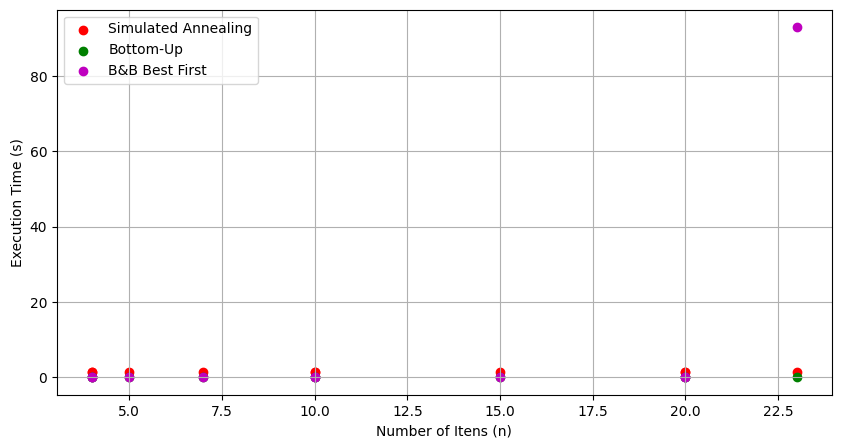

In [14]:
methods = {
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

times = {method: [] for method in methods}
n_values = []


for dataset in datasets:
    n = int(dataset[0][0])
    wmax = dataset[0][1] 
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")

    for method_name, method in methods.items():
        tic = time.perf_counter()

        if method_name == "Simulated Annealing":
            bestTaken, best_value, n_it = method(values, weights, wmax)  
            print("Estimated Best value:", bestValue)
        elif method_name == "Bottom-Up":
            bestValue, n_it = method(values, weights, wmax)  
            print("Optimal value:", bestValue)
            bestTaken = None
        else:
            knapsack_solver = method(values, weights, wmax)
            print("Chosen itens:", bestTaken)
            bestValue, bestTaken, n_it = knapsack_solver.solve()

        toc = time.perf_counter()
        times[method_name].append(toc - tic)
        print(f"{method_name} = {(toc - tic):.4}s")
        print(n_it, "iteraions \n")

    n_values.append(n)
    
# Plot exec times
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

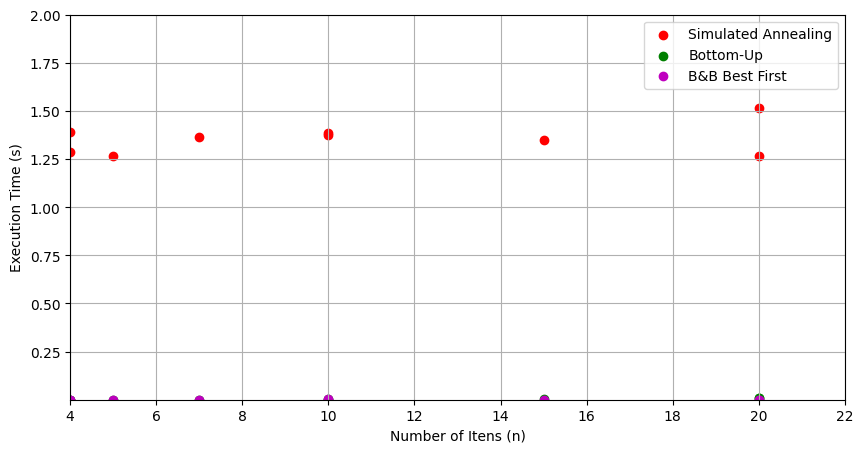

In [23]:
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlim([min(n_values), 22.0])  
plt.ylim([min(method_times), 2])  
plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

#### Large Scale

In [30]:
datasets = []
N_values = []
W_values = []
listing = os.listdir("./instances_01_KP/large_scale/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    print(infile)
    path = os.path.join("./instances_01_KP/large_scale/", infile)
    path = os.path.join("./instances_01_KP/large_scale/knapPI_1_200_1000_1")
    
    parts = infile.split("_")
    N = int(parts[2])  
    W = int(parts[3])  
    
    N_values.append(N)
    W_values.append(W)

    with open(path, "r") as f:
        lines = f.readlines()[:-1]  
    
    data = np.loadtxt(lines)
    datasets.append(data)
    break

knapPI_1_10000_1000_1


In [31]:
def timeout_handler(num, stack):
    raise Exception("Timeout")

methods = {
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    # "B&B Best First": KPBB_BestFirst
}

# Dic to store exec times
times = {method: [] for method in methods}
n_values = []

for dataset in datasets:
    n = dataset[0][0] 
    wmax = dataset[0][1]
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")
    
    for method_name, method in methods.items():
        tic = time.perf_counter()

        if method_name == "Bottom-Up":
            bestValue, n_it = method(values, weights, wmax)  
            print("Optimal value:", bestValue)
            bestTaken = None
        else:
            # signal.signal(signal.SIGALRM, timeout_handler)
            # signal.alarm(180)
            # try:
                bestTaken, best_value, n_it = method(values, weights, wmax)  
                print("Estimated Best value:", bestValue)
            # except Exception as ex:
            #     print("\nSimulated Annealing interrupted after 3min")

        toc = time.perf_counter()
        times[method_name].append(toc - tic)
        print(f"{method_name} = {(toc - tic):.4f}s, {n_it} iterations")

    n_values.append(n)
    print("Best value found:", bestValue)
    print("Chosen itens:", bestTaken)


=== Problem with 200 items and 1008 capacity ===
Estimated Best value: 130.0
Simulated Annealing = 1.7930s, 1146 iterations
Optimal value: 11238.0
Bottom-Up = 0.0634s, 200 iterations
Best value found: 11238.0
Chosen itens: None
